In [1]:
import random
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import torch

from data_center_model import DataCenterModel
from am_flexdc_training_utilities import train_model, evaluate_model

SEED = 0
DATA_FILE = "../data/flexdc_all_data.csv"
MODEL_FILE = "../models/am_flexdc_condor_flexdc_objective_v1_state_dict.pt"
Path(MODEL_FILE).parent.mkdir(parents=True, exist_ok=True)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


In [2]:
# Makes the unchanged CONDOR model architecture.
#device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
device = torch.device("cpu")
sim_model = DataCenterModel()
sim_model.to(device)
sim_model.train()

print("Device:", device)


Device: cpu


In [3]:
# Trains the three FlexDC objective components:
# [M_RSR, C_track, C_Qos].
# cross_validate=True keeps the paper-style deterministic 70/30 split.
sim_model, train_loss_record, heldout_loss_record = train_model(
    sim_model,
    epochs=150,
    lr=1e-4,
    batch_size=512,
    verbose=True,
    cross_validate=True,
    data_file_path=DATA_FILE,
)


Epoch 0 Train Loss: 347.23418804546736 Test Loss: 332.1519997914632
Epoch 1 Train Loss: 326.2826999973606 Test Loss: 331.2451759974162
Epoch 2 Train Loss: 326.7453984440984 Test Loss: 331.33053239186603
Epoch 3 Train Loss: 327.37455598298493 Test Loss: 330.6645158131917
Epoch 4 Train Loss: 325.8811173997484 Test Loss: 330.6058832804362
Epoch 5 Train Loss: 326.4421213510874 Test Loss: 330.2497380574544
Epoch 6 Train Loss: 325.87387359894075 Test Loss: 330.0289198557536
Epoch 7 Train Loss: 325.9473608893317 Test Loss: 329.9736445744832
Epoch 8 Train Loss: 324.5523732503255 Test Loss: 329.37725353240967
Epoch 9 Train Loss: 323.9939810263144 Test Loss: 326.80351479848224
Epoch 10 Train Loss: 322.1212908770587 Test Loss: 325.08113384246826
Epoch 11 Train Loss: 317.67211501662797 Test Loss: 317.22742589314777
Epoch 12 Train Loss: 306.3165483904314 Test Loss: 310.19801330566406
Epoch 13 Train Loss: 287.40775993278436 Test Loss: 273.063640276591
Epoch 14 Train Loss: 262.94841333337735 Test Los

In [4]:
# The logged FlexDC objective is reconstructed after prediction:
# C_total = M_RSR + C_track + C_Qos.


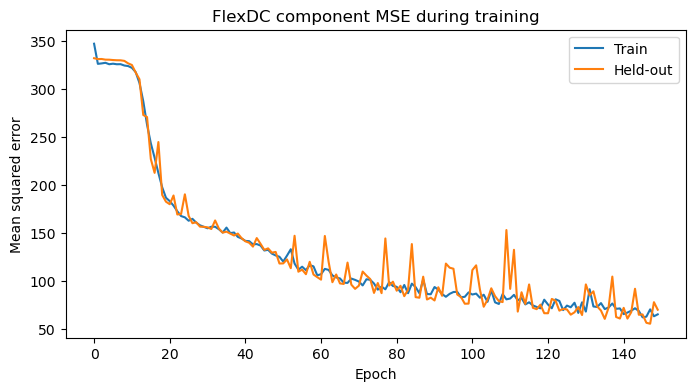

In [5]:
plt.figure(figsize=(8, 4))
plt.title("FlexDC component MSE during training")
plt.plot(train_loss_record, label="Train")
plt.plot(heldout_loss_record, label="Held-out")
plt.xlabel("Epoch")
plt.ylabel("Mean squared error")
plt.legend()
plt.show()


In [6]:
torch.save(sim_model.state_dict(), MODEL_FILE)
print(f"Saved model state dict to: {MODEL_FILE}")


Saved model state dict to: ../models/am_flexdc_condor_flexdc_objective_v1_state_dict.pt


In [7]:
loaded_model = DataCenterModel()
loaded_model.load_state_dict(torch.load(MODEL_FILE, map_location=device))
loaded_model.to(device)
loaded_model.eval()

# Uses the same deterministic 70/30 split as train_model().
y_true_train, y_pred_train, y_true_test, y_pred_test = evaluate_model(
    loaded_model,
    cross_validate=True,
    data_file_path=DATA_FILE,
)


MSE  || Train: 66.1538 | Test: 70.0342
MAPE || Train: 0.5265408 | Test: 0.53829867
C_total MSE  || Train: 199.71538 | Test: 210.94888
C_total MAPE || Train: 0.2216431 | Test: 0.22130597


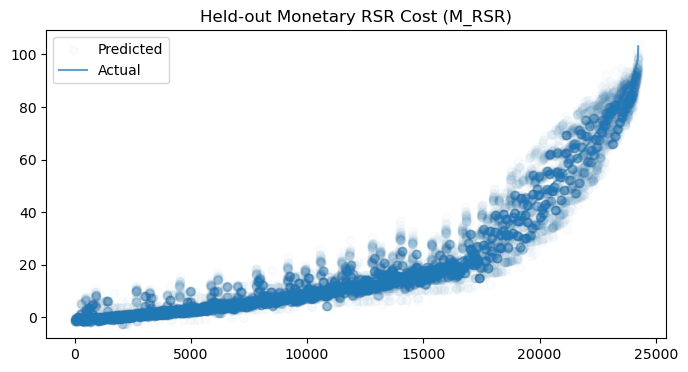

In [8]:
plt.figure(figsize=(8, 4))
plt.title("Held-out Monetary RSR Cost (M_RSR)")
ind = np.argsort(y_true_test[:, 0])
plt.scatter(range(len(ind)), y_pred_test[ind, 0], alpha=0.02, label="Predicted")
plt.plot(range(len(ind)), y_true_test[ind, 0], alpha=0.7, label="Actual")
plt.legend()
plt.show()


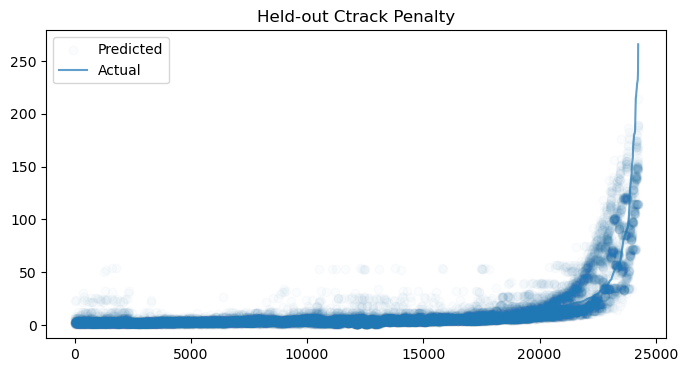

In [9]:
plt.figure(figsize=(8, 4))
plt.title("Held-out Ctrack Penalty")
ind = np.argsort(y_true_test[:, 1])
plt.scatter(range(len(ind)), y_pred_test[ind, 1], alpha=0.02, label="Predicted")
plt.plot(range(len(ind)), y_true_test[ind, 1], alpha=0.7, label="Actual")
plt.legend()
plt.show()


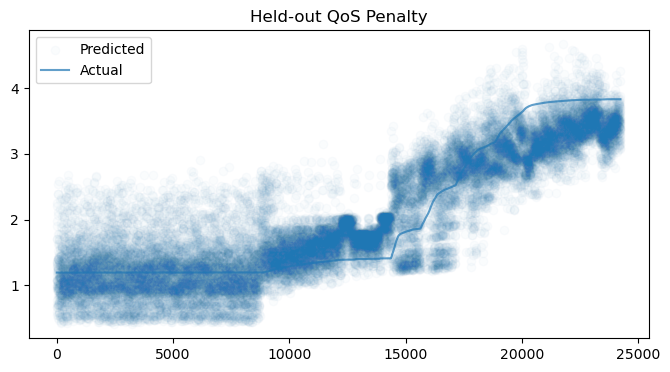

In [10]:
plt.figure(figsize=(8, 4))
plt.title("Held-out QoS Penalty")
ind = np.argsort(y_true_test[:, 2])
plt.scatter(range(len(ind)), y_pred_test[ind, 2], alpha=0.02, label="Predicted")
plt.plot(range(len(ind)), y_true_test[ind, 2], alpha=0.7, label="Actual")
plt.legend()
plt.show()


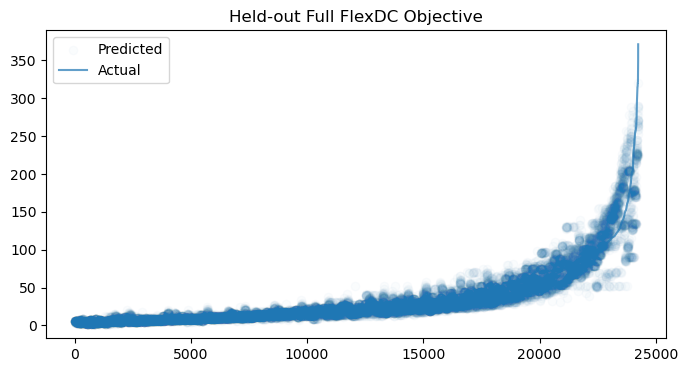

In [11]:
actual_c_total = y_true_test.sum(axis=1)
predicted_c_total = y_pred_test.sum(axis=1)

plt.figure(figsize=(8, 4))
plt.title("Held-out Full FlexDC Objective")
ind = np.argsort(actual_c_total)
plt.scatter(range(len(ind)), predicted_c_total[ind], alpha=0.02, label="Predicted")
plt.plot(range(len(ind)), actual_c_total[ind], alpha=0.7, label="Actual")
plt.legend()
plt.show()


In [12]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

names = ["M_RSR", "C_track", "C_Qos"]

actual_total = y_true_test.sum(axis=1)
predicted_total = y_pred_test.sum(axis=1)

for i, name in enumerate(names):
    actual = y_true_test[:, i]
    predicted = y_pred_test[:, i]

    print(name)
    print("  MAE: ", mean_absolute_error(actual, predicted))
    print("  RMSE:", mean_squared_error(actual, predicted) ** 0.5)
    print("  R²:  ", r2_score(actual, predicted))

print("C_total")
print("  MAE: ", mean_absolute_error(actual_total, predicted_total))
print("  RMSE:", mean_squared_error(actual_total, predicted_total) ** 0.5)
print("  R²:  ", r2_score(actual_total, predicted_total))

M_RSR
  MAE:  3.6944056
  RMSE: 5.0980902593022215
  R²:   0.9537246231160923
C_track
  MAE:  5.7270164
  RMSE: 13.560403266244116
  R²:   0.7032452724768983
C_Qos
  MAE:  0.3856411
  RMSE: 0.47840520402177383
  R²:   0.7873049160887848
C_total
  MAE:  7.898263
  RMSE: 14.524079422002643
  R²:   0.8677615585932169
